# Chapter I - Food Webs

## Read the Adjacency Matrix

<!-- py3-explanation-cell -->
### Spiegazione del blocco 1: matrice di adiacenza non orientata

**Cosa fa.** Questo blocco costruisce manualmente una matrice di adiacenza per una piccola rete non orientata con quattro nodi. Ogni riga e ogni colonna rappresentano un nodo; un valore `1` indica che esiste un collegamento tra due nodi, mentre `0` indica assenza di collegamento.

**Come funziona l'algoritmo.** Non viene ancora eseguito un algoritmo iterativo: si definisce la struttura dati di base su cui lavoreranno i blocchi successivi. La posizione `adjacency_matrix[i][j]` codifica il legame fra il nodo `i` e il nodo `j`. Poiche la rete e non orientata, la matrice e simmetrica: se il nodo 1 e collegato al nodo 2, allora e vero anche il contrario.

**Principi alla base.** La matrice di adiacenza e una rappresentazione fondamentale delle reti. Trasforma un grafo in una tabella numerica, rendendo possibili calcoli locali come grado, vicinato e clustering. E semplice da leggere e molto adatta a reti piccole; per reti grandi puo diventare costosa in memoria, perche richiede spazio proporzionale al quadrato del numero di nodi.

In [1]:
adjacency_matrix=[
                  [0,1,0,1],
                  [1,0,1,1],
                  [0,1,0,0],
                  [1,1,0,0]
                  ]

### Browsing the rows

<!-- py3-explanation-cell -->
### Spiegazione del blocco 2: visita delle righe della matrice

**Cosa fa.** Questo blocco stampa una riga alla volta della matrice di adiacenza definita prima. Serve a visualizzare la struttura della rete in forma tabellare.

**Come funziona l'algoritmo.** Il ciclo `for` scorre la lista esterna `adjacency_matrix`. Ogni elemento della lista esterna e una riga, cioe la lista dei collegamenti di un nodo verso tutti gli altri nodi. A ogni iterazione il codice stampa la riga corrente.

**Principi alla base.** Scorrere una matrice riga per riga permette di interpretare il profilo di connessione di ciascun nodo. In una matrice di adiacenza, la riga associata a un nodo contiene l'informazione sui suoi legami uscenti o, nel caso non orientato, sui suoi vicini. Questo e il primo passo per molte misure di rete: invece di pensare al grafo come disegno, lo si tratta come struttura dati interrogabile.

In [2]:
for row in adjacency_matrix:
    print(row)


[0, 1, 0, 1]
[1, 0, 1, 1]
[0, 1, 0, 0]
[1, 1, 0, 0]


### Browsing the link information

<!-- py3-explanation-cell -->
### Spiegazione del blocco 3: visita elemento per elemento

**Cosa fa.** Questo blocco stampa la matrice elemento per elemento, mantenendo la forma visiva di righe e colonne. Rispetto al blocco precedente, mostra esplicitamente come attraversare ogni cella della matrice.

**Come funziona l'algoritmo.** Ci sono due cicli annidati. Il ciclo esterno seleziona una riga della matrice; il ciclo interno visita ogni valore `a_ij` della riga. La stampa con `end=" "` evita di andare subito a capo, cosi i valori della stessa riga restano affiancati. Alla fine di ogni riga, `print()` manda a capo.

**Principi alla base.** Molti algoritmi su matrici usano cicli annidati per esaminare tutte le coppie di nodi. Ogni elemento `a_ij` puo essere interpretato come risposta alla domanda: esiste un collegamento da `i` a `j`? Questo schema di scansione e alla base del conteggio dei link, del calcolo dei gradi e di molte misure globali della rete.

In [3]:
for row in adjacency_matrix:
    for a_ij in row:
        print(a_ij, end=" ")
    print()


0 1 0 1 
1 0 1 1 
0 1 0 0 
1 1 0 0 


### Directed Networks

<!-- py3-explanation-cell -->
### Spiegazione del blocco 4: matrice di adiacenza orientata

**Cosa fa.** Questo blocco definisce una matrice di adiacenza per una rete orientata. Qui un collegamento da un nodo a un altro ha una direzione, come accade nelle reti trofiche: una specie puo nutrirsi di un'altra, e la relazione non e automaticamente reciproca.

**Come funziona l'algoritmo.** Anche in questo caso si costruisce una lista di liste. La differenza e interpretativa: `adjacency_matrix_directed[i][j] = 1` indica un arco diretto dal nodo `i` al nodo `j`. La matrice non deve essere simmetrica, perche il fatto che `i` punti a `j` non implica che `j` punti a `i`.

**Principi alla base.** Nei grafi orientati bisogna distinguere relazioni entranti e uscenti. Questa distinzione e essenziale nelle food webs: un arco puo rappresentare il flusso trofico, la predazione o una relazione preda-predatore. Da questa rappresentazione derivano grandezze come in-degree, out-degree, specie basali, specie intermedie e top predators.

In [4]:
#in the case of directed networks the adjacency matrix is not symetric, like for Food Wes
#if a non zero element is present in row 2, column 3, this means there is an arc (directed edge)
#from node 2 toward node 3
adjacency_matrix_directed=[
                  [0,1,0,1],
                  [0,0,1,0],
                  [0,0,0,1],
                  [0,0,0,0]
                  ]

## Basic Statistics

<!-- py3-explanation-cell -->
### Spiegazione del blocco 5: statistiche di base della rete orientata

**Cosa fa.** Questo blocco calcola alcune statistiche elementari della rete orientata: numero di specie, numero di predazioni o link, conteggio delle specie basali, intermedie e top, e connettanza.

**Come funziona l'algoritmo.** Prima conta i nodi usando la dimensione della matrice. Poi visita tutte le celle con due cicli annidati e incrementa `num_predations` ogni volta che trova un valore diverso da zero. In parallelo costruisce `row_count` e `column_count`: la somma di una riga misura quanti archi escono da un nodo, mentre la somma di una colonna misura quanti archi entrano nel nodo. Infine classifica ogni nodo: se non ha archi uscenti e top, se non ha archi entranti e basale, altrimenti e intermedio.

**Principi alla base.** La classificazione ecologica nasce dalla direzione dei link. Le specie basali stanno alla base della catena trofica, le intermedie sono sia prede sia predatori, le top non sono predate nella rete osservata. La connettanza misura la densita della rete: e il rapporto tra link osservati e link possibili, quindi indica quanto e intrecciata la rete rispetto alla sua dimensione.

In [8]:
#the number of species is the number of rows or columns of 
#the adjacency matrix
num_species=len(adjacency_matrix_directed[0])

#the number of links or predations is the non zero elements 
#of the adjacency matrix (this holds for directed graphs
num_predations=0
for i in range(num_species):
    for j in range(num_species):
        if adjacency_matrix_directed[i][j]!=0:
            num_predations=num_predations+1

#to check if a specie is a Basal (B), an Intermediate (I) or
#a Top (T) one  we have to check the presence of 1s both in 
#the row and in the column of each specie
row_count=[0,0,0,0]
column_count=[0,0,0,0]
for i in range(num_species):
    for j in range(num_species):
        row_count[i]=row_count[i]+adjacency_matrix_directed[i][j]
        column_count[j]=column_count[j]+ \
        adjacency_matrix_directed[i][j]

number_B=0
number_I=0
number_T=0

for n in range(num_species):
    if row_count[n]==0:
        number_T+=1
        continue
    if column_count[n]==0:
        number_B+=1
        continue
    else:
        number_I+=1
   
print("number of species", num_species)
print("number of predations", num_predations)
print("classes Basal, Top, Intermediate: ",number_B,number_T,number_I)
print("connectance", float(num_predations)/float(num_species**2))


number of species 4
number of predations 4
classes Basal, Top, Intermediate:  1 1 2
connectance 0.25


## The Degree

<!-- py3-explanation-cell -->
### Spiegazione del blocco 6: grado, in-degree e out-degree

**Cosa fa.** Questo blocco calcola il grado di un nodo nella rete non orientata e poi recupera out-degree e in-degree in quella orientata usando i conteggi gia calcolati.

**Come funziona l'algoritmo.** Per il grafo non orientato, il codice somma i valori della seconda riga della matrice: ogni `1` corrisponde a un vicino del nodo 2. Per il grafo orientato, invece, non ricalcola tutto: usa `row_count[2]` come out-degree del nodo 3 e `column_count[3]` come in-degree del nodo 4.

**Principi alla base.** Il grado misura quante connessioni ha un nodo. Nei grafi orientati questa misura si divide in due: l'out-degree conta gli archi uscenti, l'in-degree quelli entranti. Nelle reti trofiche queste due quantita hanno significati ecologici distinti, perche possono indicare quante risorse consuma una specie e da quanti predatori viene consumata.

In [9]:
#for the undirected network
degree_node_2=0
for j in adjacency_matrix[1]:
    degree_node_2=degree_node_2+j
print("degree of node 2:",degree_node_2)

#and for the directed case we already calculated the sum over 
#the rows and columns for the adjacency_matrix_directed
out_degree_node_3=row_count[2]
in_degree_node_4=column_count[3]

print("out_degree node 3:",out_degree_node_3)
print("in_degree node 4:",in_degree_node_4)


degree of node 2: 3
out_degree node 3: 1
in_degree node 4: 2


## Degree in Networkx

<!-- py3-explanation-cell -->
### Spiegazione del blocco 7: costruzione del grafo con NetworkX

**Cosa fa.** Questo blocco installa/importa NetworkX, crea un grafo non orientato, aggiunge nodi e archi, e chiede alla libreria il grado del nodo 2.

**Come funziona l'algoritmo.** Invece di manipolare direttamente la matrice, il codice usa l'oggetto `Graph` di NetworkX. Prima crea un grafo vuoto, poi inserisce i nodi con `add_node` e i collegamenti con `add_edge`. Quando chiama `G.degree(2)`, NetworkX conta internamente quanti archi sono incidenti sul nodo 2.

**Principi alla base.** Una libreria di grafi offre astrazioni piu vicine al concetto matematico di rete. Il grafo non e solo una matrice: e un insieme di nodi e archi con metodi per calcolare proprieta strutturali. Questo riduce il rischio di errori e permette di usare algoritmi gia implementati, testati e ottimizzati, come visite, componenti connesse e misure di centralita.

In [14]:
%pip install networkx
import networkx as nx

#generate an empty graph
G=nx.Graph()

#define the nodes
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)

#link the nodes
G.add_edge(1,2)
G.add_edge(1,4)
G.add_edge(2,3)
G.add_edge(2,4)

#degree of the node 2
print(G.degree(2))



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


AttributeError: 'wrapper_descriptor' object has no attribute '__annotate__'

### Degree sequence

<!-- py3-explanation-cell -->
### Spiegazione del blocco 8: sequenza dei gradi

**Cosa fa.** Questo blocco calcola la sequenza dei gradi della rete non orientata, cioe la lista dei gradi di tutti i nodi.

**Come funziona l'algoritmo.** Il ciclo esterno visita ogni riga della matrice. Per ogni riga inizializza `degree` a zero e somma tutti i valori della riga. Poiche ogni `1` rappresenta un collegamento, la somma della riga e il grado del nodo corrispondente. Il risultato viene aggiunto a `degree_sequence`, che alla fine contiene un grado per ogni nodo.

**Principi alla base.** La sequenza dei gradi e una descrizione compatta dell'eterogeneita della rete. Due reti possono avere lo stesso numero di nodi e link ma distribuzioni dei gradi molto diverse. Nelle reti complesse, osservare la distribuzione dei gradi aiuta a capire se la rete e omogenea, se contiene hub, o se segue pattern tipici di reti biologiche, sociali o tecnologiche.

In [ ]:
degree_sequence=[]
for row in range(len(adjacency_matrix)):
    degree=0
    for j in adjacency_matrix[row]:
        degree=degree+j
    degree_sequence.append(degree)

print(degree_sequence)


[2, 3, 1, 2]


## Histogram

<!-- py3-explanation-cell -->
### Spiegazione del blocco 9: attivazione dei grafici nel notebook

**Cosa fa.** Questo blocco abilita la visualizzazione inline dei grafici Matplotlib dentro il notebook. Non calcola una misura di rete, ma prepara l'ambiente per le visualizzazioni successive.

**Come funziona l'algoritmo.** La direttiva `%matplotlib inline` e una magic command di IPython/Jupyter. Dice al kernel di renderizzare le figure Matplotlib come output della cella, invece di aprirle in una finestra esterna.

**Principi alla base.** Nei notebook computazionali, calcolo e visualizzazione sono integrati. La visualizzazione e parte dell'analisi: permette di controllare rapidamente distribuzioni, strutture e risultati intermedi. Per le reti complesse, i grafici non sostituiscono le misure quantitative, ma aiutano a interpretarle e a individuare pattern o anomalie.

In [ ]:
# this command is to activate the graphic interface
%matplotlib inline


<!-- py3-explanation-cell -->
### Spiegazione del blocco 10: istogramma di esempio

**Cosa fa.** Questo blocco importa Matplotlib, crea un istogramma da una piccola lista di valori e lo mostra nel notebook. E un esempio di visualizzazione di una distribuzione.

**Come funziona l'algoritmo.** `plt.hist` divide l'intervallo dei valori osservati in un numero fissato di classi, o bin, e conta quanti valori cadono in ogni classe. Con `bins=5` si richiedono cinque intervalli. `plt.show()` forza la visualizzazione della figura.

**Principi alla base.** Un istogramma stima la forma di una distribuzione empirica. Nel contesto delle reti, lo stesso principio puo essere usato per visualizzare la distribuzione dei gradi, delle distanze, dei coefficienti di clustering o di altre misure. La scelta dei bin influenza la granularita: pochi bin mostrano la tendenza generale, molti bin mostrano piu dettaglio ma possono rendere il grafico rumoroso.

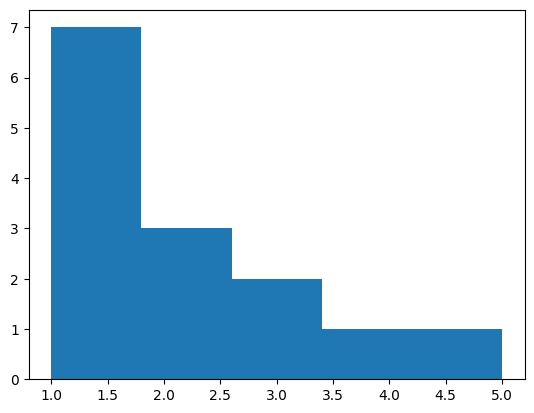

In [ ]:
import matplotlib.pyplot as plt

plt.hist([1,1,1,1,1,1,1,2,2,2,3,3,4,5],bins=5)
plt.show()

## Clustering Coefficient

<!-- py3-explanation-cell -->
### Spiegazione del blocco 11: coefficiente di clustering locale

**Cosa fa.** Questo blocco calcola manualmente il coefficiente di clustering del nodo 2 nella rete non orientata. La misura quantifica quanto i vicini di un nodo sono collegati tra loro.

**Come funziona l'algoritmo.** Prima individua i vicini del nodo leggendo la riga corrispondente nella matrice di adiacenza. Poi considera tutte le coppie di vicini e controlla se esiste un link fra loro. Il conteggio viene diviso per due perche, in una matrice simmetrica, ogni collegamento non orientato viene contato due volte. Infine divide i link effettivi fra vicini per il numero massimo possibile di link fra quei vicini, cioe `k(k-1)/2`, dove `k` e il grado del nodo.

**Principi alla base.** Il clustering locale misura la tendenza a formare triangoli. In molte reti reali, se A e collegato a B e C, allora B e C hanno probabilita elevata di essere collegati. In ecologia puo indicare ridondanza o chiusura locale nelle interazioni; nelle reti sociali rappresenta gruppi coesi o comunita locali.

In [ ]:
row=1 #stands for the node 2
node_index_count=0
node_index_list=[]
for a_ij in adjacency_matrix[row]:
    if a_ij==1:
        node_index_list.append(node_index_count)
    node_index_count=node_index_count+1    
print()

print(node_index_list)

#then we will check for all the possible neighbours couples if a link actually exist:

neighb_conn=0
for n1 in node_index_list:
    for n2 in node_index_list:
        if adjacency_matrix[n1][n2]==1:
            neighb_conn=neighb_conn+1
   
#we have indeed counted them twice...
neighb_conn=neighb_conn/2.0

print(neighb_conn)

#Finally the clustering coefficient for node '2' is given by the expression:

clustering_coefficient=neighb_conn/ \
(degree_node_2*(degree_node_2-1)/2.0) 

print(clustering_coefficient)



[0, 2, 3]
1.0
0.3333333333333333


## Generating the bowtie stucture

<!-- py3-explanation-cell -->
### Spiegazione del blocco 12: componente bow-tie nella rete trofica Ythan

**Cosa fa.** Questo blocco legge una rete trofica dal file `Ythan_Estuary.txt`, costruisce un grafo orientato, rimuove il nodo ambiente `0`, trova la componente fortemente connessa piu grande e visualizza una struttura bow-tie composta da componente IN, componente fortemente connessa e componente OUT.

**Come funziona l'algoritmo.** Il file viene letto riga per riga: ogni riga produce un arco diretto tra due nodi. NetworkX calcola poi le componenti fortemente connesse, cioe insiemi di nodi in cui ogni nodo puo raggiungere ogni altro seguendo la direzione degli archi. La piu grande viene usata come nucleo centrale. I predecessori esterni dei nodi nel nucleo formano la parte IN, mentre i successori esterni formano la parte OUT. Il codice crea un sottografo con queste tre parti, assegna manualmente coordinate ai nodi e li disegna con colori diversi.

**Principi alla base.** La decomposizione bow-tie e utile per reti dirette con flussi: distingue cio che puo arrivare al nucleo, il nucleo reciprocamente raggiungibile, e cio che e raggiungibile dal nucleo. Nelle reti trofiche questa idea aiuta a leggere organizzazione, cicli e direzioni principali del flusso ecologico. La componente fortemente connessa rappresenta reciprocita raggiungibile lungo percorsi diretti, non necessariamente predazione reciproca immediata.

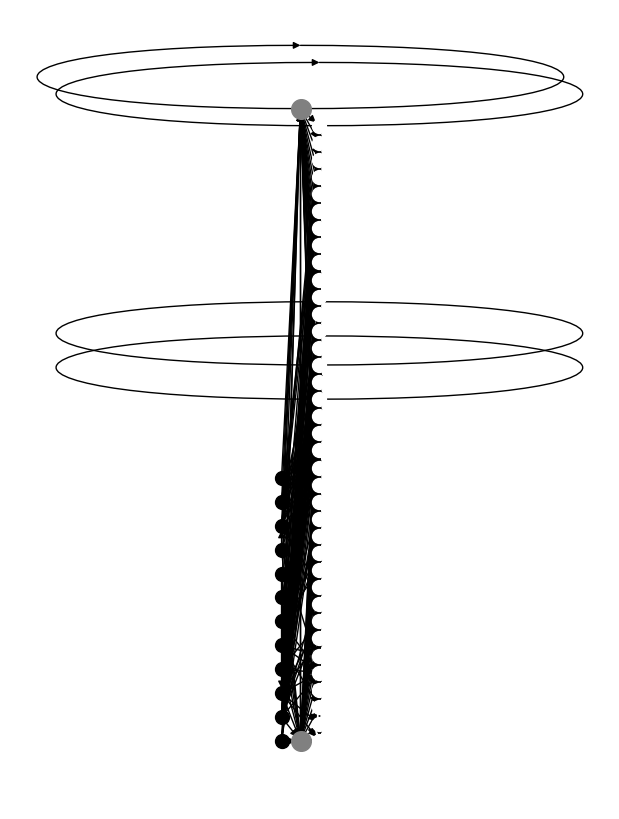

In [ ]:
#loading the network
file_name="./data/Ythan_Estuary.txt"

DG = nx.DiGraph()

with open(file_name, 'r') as in_file:
    for next_line in in_file:
        next_line_fields=next_line.strip().split()
        if len(next_line_fields) < 2:
            continue
        node_a=next_line_fields[0]
        node_b=next_line_fields[1]
        DG.add_edge(node_a, node_b)

#deleting the environment
DG.remove_node('0')

#getting the biggest strongly connected component
scc=sorted(sorted(nx.strongly_connected_components(DG), key=len, reverse=True)[0])

#preparing the IN and OUT component
IN_component=[]
for n in scc:
    for s in DG.predecessors(n):
        if s in scc: continue
        if not s in IN_component:
            IN_component.append(s)
            
OUT_component=[]
for n in scc:
    for s in DG.successors(n):
        if s in scc: continue
        if not s in OUT_component:
            OUT_component.append(s)

#generating the subgraph
bowtie=scc+IN_component+OUT_component
DG_bowtie = DG.subgraph(bowtie)

#defining the proper layout
pos={}
in_y=100.
pos['89']=(150.,in_y)

in_step=700.
for in_n in IN_component:
    pos[in_n]=(100.,in_y)
    in_y=in_y+in_step

out_y=100.
out_step=500.   
for out_n in OUT_component:
    pos[out_n]=(200,out_y)
    out_y=out_y+out_step

pos['90']=(150.,out_y)
    
#plot the bowtie structure
plt.figure(figsize=(6, 8))
nx.draw(DG_bowtie, pos, node_size=50)

nx.draw_networkx_nodes(DG_bowtie, pos, IN_component, \
                       node_size=100, node_color='Black')
nx.draw_networkx_nodes(DG_bowtie, pos, OUT_component, \
                       node_size=100, node_color='White')
nx.draw_networkx_nodes(DG_bowtie, pos, scc, \
                       node_size=200, node_color='Grey')

plt.savefig('./data/bowtie.png',dpi=600)


## Distance with Breadth First Search

### create the undirected graph

<!-- py3-explanation-cell -->
### Spiegazione del blocco 13: grafo di esempio per la visita in ampiezza

**Cosa fa.** Questo blocco costruisce un grafo non orientato con nodi etichettati da lettere, stampa i vicini del nodo `A` e disegna il grafo. Prepara l'esempio per il calcolo delle distanze nel blocco successivo.

**Come funziona l'algoritmo.** Il grafo viene creato con `nx.Graph()` e popolato usando `add_edges_from`, che inserisce automaticamente sia gli archi sia i nodi coinvolti. `G.neighbors('A')` restituisce i nodi direttamente collegati ad `A`. La chiamata `nx.draw(G)` produce una visualizzazione rapida della rete.

**Principi alla base.** Un grafo non orientato descrive relazioni simmetriche: se `A` e collegato a `B`, allora `B` e collegato ad `A`. Il concetto di vicinato e centrale per molte misure, perche il comportamento globale di una rete spesso emerge da relazioni locali. Questo esempio introduce il terreno per la distanza geodetica, cioe il numero minimo di archi necessari per raggiungere un nodo da un altro.

['B', 'C']


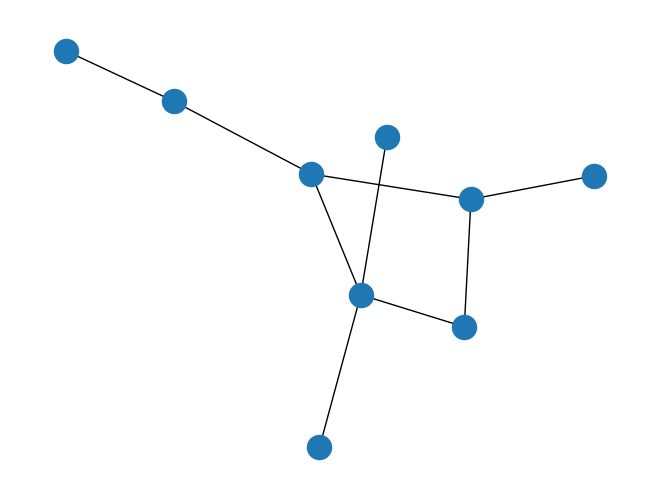

In [ ]:
#creating the graph
G=nx.Graph()
G.add_edges_from([('A','B'),('A','C'),('C','D'),('C','E'),('D','F'),
('D','H'),('D','G'),('E','H'),('E','I')])

#printing the neighbors of the node 'A'
print(list(G.neighbors('A')))

nx.draw(G)


<!-- py3-explanation-cell -->
### Spiegazione del blocco 14: visita in ampiezza e distanze dal nodo radice

**Cosa fa.** Questo blocco calcola la distanza di ogni nodo dal nodo radice `A` usando una visita in ampiezza, nota come Breadth-First Search o BFS.

**Come funziona l'algoritmo.** Si inizializza una coda con il nodo radice e si assegna distanza zero ad `A`. Finche la coda non e vuota, il codice estrae il primo nodo, visita i suoi vicini e assegna a ogni vicino non ancora visitato una distanza pari alla distanza del nodo corrente piu uno. Il vicino viene poi inserito in coda. La coda garantisce che i nodi siano esplorati per livelli: prima distanza 1, poi distanza 2, e cosi via.

**Principi alla base.** La BFS trova distanze minime in grafi non pesati, perche esplora tutti i percorsi con un certo numero di archi prima di passare a percorsi piu lunghi. Questo principio e alla base del calcolo delle distanze geodetiche, della raggiungibilita e di molte misure di centralita basate sui cammini minimi.

In [ ]:
root_node='A'
queue=[]
queue.append('A')
G.nodes['A']["distance"]=0
while len(queue):
    working_node=queue.pop(0)
    for n in G.neighbors(working_node):
        if len(G.nodes[n])==0:
            G.nodes[n]["distance"]=G.nodes[working_node]["distance"]+1
            queue.append(n)
for n in G.nodes():
    print(n,G.nodes[n]["distance"])
    


A 0
B 1
C 1
D 2
E 2
F 3
H 3
G 3
I 3


## Reading the file with Food Web data

<!-- py3-explanation-cell -->
### Spiegazione del blocco 15: lettura della rete Little Rock Lake

**Cosa fa.** Questo blocco legge dal file `Little_Rock_Lake.txt` una rete trofica orientata, stampa ogni arco letto e costruisce il grafo diretto `DG`.

**Come funziona l'algoritmo.** Il file viene aperto e percorso riga per riga. Ogni riga viene ripulita con `strip()` e separata in campi con `split()`. Se la riga contiene almeno due valori, questi vengono interpretati come nodo sorgente e nodo destinazione. Il codice stampa la coppia e aggiunge l'arco corrispondente con `DG.add_edge(node_a, node_b)`.

**Principi alla base.** Molti dataset di reti sono salvati come edge list: ogni riga rappresenta un link. Questa forma e compatta per reti sparse, cioe reti in cui il numero di link e molto minore del numero massimo possibile. Convertire una edge list in un grafo NetworkX permette poi di applicare algoritmi di analisi strutturale senza dover manipolare manualmente l'intera matrice di adiacenza.

In [ ]:
file_name="./data/Little_Rock_Lake.txt"

DG = nx.DiGraph()

with open(file_name, 'r') as in_file:
    for next_line in in_file:
        next_line_fields=next_line.strip().split()
        if len(next_line_fields) < 2:
            continue
        node_a=next_line_fields[0]
        node_b=next_line_fields[1]
        print(node_a,node_b)
        DG.add_edge(node_a, node_b)


0 11
0 61
0 80
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
0 145
0 146
0 147
0 148
0 149
0 150
0 151
0 152
0 153
0 154
0 155
0 156
0 157
0 158
0 159
0 160
0 161
0 162
0 163
0 164
0 165
0 166
0 167
0 168
0 169
0 170
0 171
0 172
0 173
0 174
0 175
0 176
0 177
0 178
0 179
0 180
0 181
0 182
1 2
1 4
1 6
1 8
1 9
1 13
1 14
2 4
2 116
3 2
3 4
3 6
3 8
3 9
3 13
3 14
3 116
4 4
4 116
5 2
5 4
5 6
5 8
5 9
5 13
5 14
5 116
6 4
6 116
7 2
7 4
7 6
7 8
7 9
7 13
7 14
7 116
8 4
8 116
9 2
9 4
9 6
9 8
9 9
9 116
10 2
10 4
10 6
10 8
10 9
11 2
11 6
11 8
11 9
11 10
12 1
12 3
12 5
12 6
12 7
12 8
12 10
12 13
12 14
12 15
12 16
12 23
12 24
12 36
12 41
12 78
13 1
13 3
13 5
13 7
13 8
13 10
13 13
13 14
13 16
13 23
13 24
13 41
13 78
14 1
14 2
14 3
14 5
14 7
14 8
14 10
14 13
14 14
14 16
14 23
14 24
14 41
14 78
15 1
15 2
15 3
15 5
15 7
15 8
15 10
15 13
15 14
15 15
15 16
15 23
15 24
15 41
15 78
16 1
16 2
16 3
16 5
16 6
16 7
16 8
16 9
16 10

## Trophic Species

## Defining the trophic pattern key
this is a way to generate a unique key starting from the ordered lists of preys and predators attached to nodes

<!-- py3-explanation-cell -->
### Spiegazione del blocco 16: chiave trofica di un nodo

**Cosa fa.** Questo blocco definisce la funzione `get_node_key`, che costruisce una chiave descrittiva per un nodo in base alle sue prede e ai suoi predatori nella rete diretta.

**Come funziona l'algoritmo.** La funzione raccoglie prima tutti i nodi raggiunti dagli archi uscenti del nodo, cioe i suoi successori. Poi raccoglie tutti i nodi da cui arrivano archi entranti, cioe i suoi predecessori. Entrambe le liste vengono ordinate per rendere la chiave stabile e confrontabile. Tra le due parti viene inserito il separatore `'-'`, poi la lista delle entrate viene aggiunta alla lista delle uscite.

**Principi alla base.** Due specie possono essere considerate troficamente equivalenti se hanno lo stesso pattern di relazioni: consumano le stesse risorse e sono consumate dagli stessi predatori. La chiave trofica trasforma questo pattern relazionale in un oggetto confrontabile. Ordinare le liste e importante perche l'equivalenza non deve dipendere dall'ordine in cui NetworkX restituisce gli archi.

In [ ]:
def get_node_key(node):
    out_list=[]
    for out_edge in DG.out_edges(node):
        out_list.append(out_edge[1])
    in_list=[]
    for in_edge in DG.in_edges(node):
        in_list.append(in_edge[0])
    out_list.sort()
    out_list.append('-')
    in_list.sort()
    out_list.extend(in_list)
    return out_list

## Grouping the Trophic Species and Regenerating the Trophic network

<!-- py3-explanation-cell -->
### Spiegazione del blocco 17: aggregazione in specie trofiche

**Cosa fa.** Questo blocco definisce `TrophicNetwork`, una funzione che raggruppa nodi con la stessa chiave trofica e rimuove duplicati funzionali dalla rete. Poi rimuove il nodo ambiente `0`, costruisce la rete trofica aggregata e stampa numero di nodi, numero di link e rapporto link/specie.

**Come funziona l'algoritmo.** La funzione crea un dizionario `trophic` in cui ogni chiave e il pattern prodotto da `get_node_key`, e ogni valore e la lista dei nodi che condividono quel pattern. Se piu nodi hanno la stessa chiave, il codice conserva il primo e rimuove gli altri dal grafo. Dopo l'aggregazione, il grafo contiene una sola rappresentante per ogni gruppo troficamente equivalente.

**Principi alla base.** L'aggregazione in specie trofiche riduce la complessita della rete mantenendo ruoli ecologici distinti. Il principio e quello dell'equivalenza strutturale: nodi con identiche relazioni verso il resto della rete possono essere trattati come un'unita funzionale. Questo aiuta a confrontare reti e a calcolare statistiche meno influenzate da duplicazioni di specie con comportamento identico.

In [ ]:
def TrophicNetwork(DG):
    trophic={}
    for n in DG.nodes():
        k=tuple(get_node_key(n))
        if k not in trophic:
            trophic[k]=[]
        trophic[k].append(n)
    for specie in trophic.keys():
        if len(trophic[specie])>1:
            for n in trophic[specie][1:]:
                DG.remove_node(n)
    return DG

#deleting the environment
DG.remove_node('0')

TrophicDG=TrophicNetwork(DG)
print("S:",TrophicDG.number_of_nodes())
print("L:",TrophicDG.number_of_edges())
print("L/S:",float(TrophicDG.number_of_edges())/ \
TrophicDG.number_of_nodes())


S: 93
L: 1034
L/S: 11.118279569892474


## Classes in Food Webs

<!-- py3-explanation-cell -->
### Spiegazione del blocco 18: classificazione basale, intermedia e top

**Cosa fa.** Questo blocco definisce una funzione che classifica le specie della rete trofica aggregata in basali, intermedie e top, poi stampa la proporzione di ciascuna classe.

**Come funziona l'algoritmo.** La funzione visita tutti i nodi del grafo diretto. Se un nodo ha in-degree uguale a zero viene classificato come basale; se ha out-degree uguale a zero viene classificato come top; altrimenti viene classificato come intermedio. Dopo la classificazione, il codice divide la numerosita di ogni classe per il totale dei nodi classificati, ottenendo proporzioni confrontabili fra reti di dimensioni diverse.

**Principi alla base.** La posizione trofica di una specie puo essere approssimata attraverso la direzione dei link. Le specie basali non ricevono link entranti nella convenzione usata dal notebook, le top non hanno link uscenti, e le intermedie partecipano a entrambi i lati della relazione. Le proporzioni B/I/T descrivono l'architettura verticale della rete e sono indicatori classici nell'analisi delle food webs.

In [ ]:
def compute_classes(DG):
    basal_species=[]
    top_species=[]
    intermediate_species=[]
    for n in DG.nodes():
        if DG.in_degree(n)==0:
            basal_species.append(n)
        elif DG.out_degree(n)==0:
            top_species.append(n)
        else:
            intermediate_species.append(n)
    return (basal_species,intermediate_species,top_species)

(B,I,T)=compute_classes(TrophicDG)
print("B:",float(len(B))/(len(B)+len(T)+len(I)))
print("I:",float(len(I))/(len(B)+len(T)+len(I)))
print("T:",float(len(T))/(len(B)+len(T)+len(I)))


B: 0.12903225806451613
I: 0.8602150537634409
T: 0.010752688172043012


## Proportion of links among classes and ratio prey/predators

<!-- py3-explanation-cell -->
### Spiegazione del blocco 19: proporzione dei link fra classi e rapporto prede/predatori

**Cosa fa.** Questo blocco calcola quanta parte dei link della rete collega diverse classi trofiche: basali-top, basali-intermedie, intermedie-intermedie e intermedie-top. Calcola anche il rapporto tra numero di prede potenziali e predatori potenziali.

**Come funziona l'algoritmo.** La funzione `InterclassLinkProportion` prende due insiemi di nodi e controlla tutte le coppie possibili tra le due classi. Ogni volta che nel grafo esiste un arco da un nodo della prima classe a un nodo della seconda, incrementa il conteggio. Il risultato viene diviso per il numero totale di archi, ottenendo una proporzione. Il rapporto `P/R` confronta le specie che possono essere risorse, basali e intermedie, con quelle che possono essere predatori, intermedie e top.

**Principi alla base.** Le proporzioni interclasse descrivono come il flusso trofico e distribuito tra livelli funzionali. Non basta sapere quante specie appartengono a ogni classe: bisogna anche sapere come le classi interagiscono. Queste misure aiutano a distinguere reti con la stessa composizione B/I/T ma con organizzazioni dei link molto diverse.

In [ ]:
def InterclassLinkProportion(DG,C1,C2):
    count=0
    for n1 in C1:
        for n2 in C2:
            if DG.has_edge(n1,n2):
                count+=1
    return float(count)/DG.number_of_edges()
    
print("links in BT:",InterclassLinkProportion(TrophicDG,B,T))
print("links in BI:",InterclassLinkProportion(TrophicDG,B,I))
print("links in II:",InterclassLinkProportion(TrophicDG,I,I))
print("links in IT:",InterclassLinkProportion(TrophicDG,I,T))

#Ratio prey/predators
print("P/R:",float((len(B)+len(I)))/(len(I)+len(T)))


links in BT: 0.0009671179883945841
links in BI: 0.09090909090909091
links in II: 0.9081237911025145
links in IT: 0.0
P/R: 1.1358024691358024


<!-- py3-explanation-cell -->
### Spiegazione del blocco 20: cella vuota finale

**Cosa fa.** Questa cella di codice e vuota e non esegue alcuna operazione. Funziona come spazio disponibile per eventuali esperimenti successivi o nuove analisi.

**Come funziona l'algoritmo.** Non c'e un algoritmo associato, perche non contiene istruzioni. Se in futuro venisse usata, il kernel eseguirebbe le istruzioni inserite in questa posizione mantenendo disponibili le variabili definite nelle celle precedenti.

**Principi alla base.** Nei notebook e comune lasciare una cella vuota come punto di lavoro. Dal punto di vista computazionale, una cella vuota non modifica lo stato del kernel e non produce output. Dal punto di vista didattico, segnalarla evita ambiguita: il flusso concettuale del notebook termina con le misure interclasse del blocco precedente.